# SRA 결정 변환기: 라우팅 분석

이 데모에서는 SRA를 강화 학습을 위한 **의사결정 변환기(DT)**로 사용하고 에이전트가 다양한 GridWorld 작업(예: 보물찾기, 탈출)을 해결할 때 '두뇌 사용'을 분석합니다.

여기서 우리는 두 가지 점을 시각화합니다.
1. **작업 분리**: '탈출'과 '보물'에 사용되는 시냅스의 편향.
2. **인식과 행동의 분리**: 입력 토큰 유형('상태', '보상', '행동')에 따라 할당된 시냅스가 어떻게 변하는가.

## 1. 환경 설정

In [1]:
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. 모델 및 작업 준비
16명의 전문가(시냅스)로 모델을 정의합니다.

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.sra_language_models import MoESRALanguageModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)
from src.sra_gridworld import generate_trajectory, make_dt_batch
from src.sra_experiment import make_optimizer, load_balance_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

config = MoESRAConfig(
    vocab_size=100,
    d_model=64,
    n_layers=2,
    n_heads=2,
    num_synapses=16, # Prepare 16 experts
    k=2,
    max_seq_len=64
)
model = MoESRALanguageModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128, max_seq_len=200, pad_idx=0).to(device)
optimizer = make_optimizer(model, lr=0.005)

Using device: cpu


## 3. 미니 트레이닝 루프
`treasure` 및 `escape`에 대한 궤적을 무작위로 생성하고 단 50단계만 훈련합니다.(Colab에서 빠르게 완료되도록 짧게 유지)

In [3]:
print("Training Decision Transformer...")
model.train()

epochs = 150
batch_size = 32
max_steps = 10

for epoch in range(epochs):
    x, y, _ = make_dt_batch(batch_size, max_steps, device)
    
    optimizer.zero_grad()
    outputs, routing_weights = model(x)
    
    # Calculate loss only for action predictions
    loss = F.cross_entropy(outputs.reshape(-1, config.vocab_size), y.reshape(-1), ignore_index=-100)
    
    lb_loss = load_balance_loss(routing_weights) * 0.1
    total_loss = loss + lb_loss
    
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

print("Training finished!")

Training Decision Transformer...


Epoch 50/150 | Loss: 1.0572


Epoch 100/150 | Loss: 0.8066


Epoch 150/150 | Loss: 0.8108
Training finished!


## 4. 라우팅 분석: 작업별 시냅스 사용량
훈련 후 라우터가 '보물'과 '탈출'에 우선적으로 사용하는 시냅스를 집계하고 비교합니다.

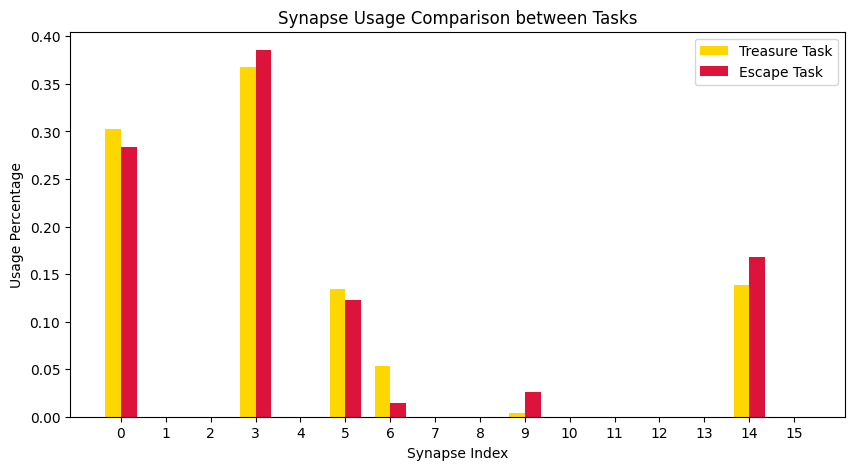

💡 [Insight] You can see that the height of the bars differs depending on the task (= different synapses are used).
The router assigns the 'policy to escape from pursuers' and the 'policy to approach the treasure' to different synapses.


In [4]:
def analyze_task_usage(task_type, samples=50):
    model.eval()
    usage_counts = torch.zeros(config.num_synapses, device=device)
    
    with torch.no_grad():
        for _ in range(samples):
            traj = generate_trajectory(task_type, max_steps=5)
            x = torch.tensor([traj], dtype=torch.long).to(device)
            _, routing_weights = model(x)
            
            # Aggregate the indices of synapses used in the final layer's routing
            layer_weights = routing_weights[-1][0]  # [seq_len, n_synapses]
            chosen = layer_weights.argmax(dim=-1)
            usage_counts += torch.bincount(chosen, minlength=config.num_synapses)
            
    usage_pct = (usage_counts / usage_counts.sum()).cpu().numpy()
    return usage_pct

usage_treasure = analyze_task_usage("treasure")
usage_escape = analyze_task_usage("escape")

# Compare using a bar chart
plt.figure(figsize=(10, 5))
x = np.arange(config.num_synapses)
width = 0.35

plt.bar(x - width/2, usage_treasure, width, label='Treasure Task', color='gold')
plt.bar(x + width/2, usage_escape, width, label='Escape Task', color='crimson')

plt.ylabel('Usage Percentage')
plt.xlabel('Synapse Index')
plt.title('Synapse Usage Comparison between Tasks')
plt.xticks(x)
plt.legend()
plt.show()

print("💡 [Insight] You can see that the height of the bars differs depending on the task (= different synapses are used).")
print("The router assigns the 'policy to escape from pursuers' and the 'policy to approach the treasure' to different synapses.")

## 5. 라우팅 분석: 인식과 행동의 분리(토큰별 시각화)
단일 '보물' 궤적의 경우 상태, 보상, 행동에 대한 각 토큰이 할당된 시냅스를 히트맵을 통해 확인하세요.

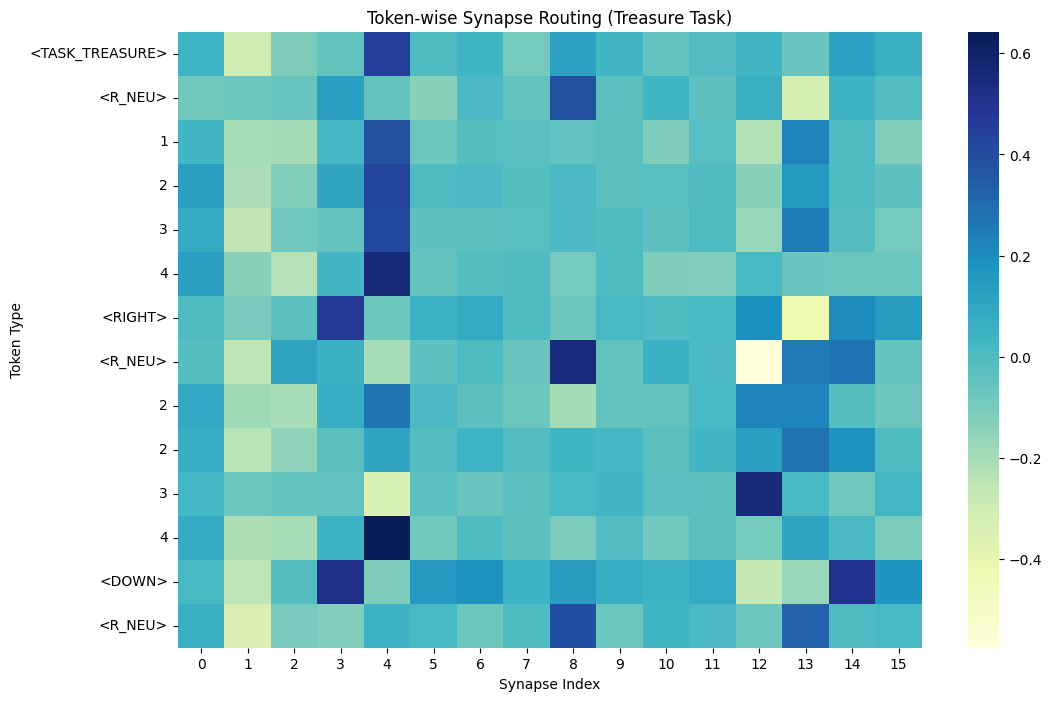

💡 [Insight] Looking at the vertical labels, you can observe that for each data type such as 'State', 'Reward', and 'Action',
the darker synapses (horizontal axis) are cleanly separated.


In [5]:
model.eval()
traj = generate_trajectory("treasure", max_steps=2)
x = torch.tensor([traj], dtype=torch.long).to(device)

with torch.no_grad():
    _, routing_weights = model(x)

weights = routing_weights[0][0].cpu().numpy()
from src.constants import ID2TOK
labels = [ID2TOK.get(t, str(t)) for t in traj]

plt.figure(figsize=(12, 8))
sns.heatmap(weights, cmap="YlGnBu", yticklabels=labels, annot=False)
plt.title("Token-wise Synapse Routing (Treasure Task)")
plt.xlabel("Synapse Index")
plt.ylabel("Token Type")
plt.show()

print("💡 [Insight] Looking at the vertical labels, you can observe that for each data type such as 'State', 'Reward', and 'Action',")
print("the darker synapses (horizontal axis) are cleanly separated.")